<a href="https://colab.research.google.com/github/Forla03/Deep-Learning-Project---July-2026/blob/main/Deep_Learning_Project_July_Forlani_Francesco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
# SETUP

from __future__ import annotations

import json
import os
import random
import shutil
import subprocess
import sys
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [75]:
# CONFIG

@dataclass(frozen=True)
class Config:
    TRAIN_CSV_PATH: str = "data/white_to_black_train.csv"
    TEST_CSV_PATH: str = "data/white_to_black_test.csv"
    ARTIFACT_DIR: str = "artifacts"

    TRAIN_GDRIVE_ID: str = "1aQF9QQO0GgNLgv13bf5BfExaVij2OowX"
    TEST_GDRIVE_ID: str = "1z6ik6MyTjZLVvdsCKTFAgsL6uiSbeKs6"

    MAX_LEN: int = 60
    WHITE_VOCAB_SIZE: int = 20_000
    BLACK_VOCAB_SIZE: int = 20_000

    EMBEDDING_DIM: int = 128
    RNN_UNITS: int = 256
    BOTTLENECK_DIM: int = 256
    DROPOUT: float = 0.25
    SPATIAL_DROPOUT: float = 0.10

    BATCH_SIZE: int = 64
    PREDICTION_BATCH_SIZE: int = 32
    EPOCHS: int = 30
    VALIDATION_FRACTION: float = 0.10
    LEARNING_RATE: float = 1e-3

    SEED: int = 42

    BEST_WEIGHTS_NAME: str = "white_to_black_bigru_best.weights.h5"
    FINAL_WEIGHTS_NAME: str = "white_to_black_bigru_final.weights.h5"
    METADATA_NAME: str = "white_to_black_metadata.json"


CFG = Config()

In [76]:
# RUNTIME

def set_reproducibility(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def configure_runtime() -> None:
    gpus = tf.config.list_physical_devices("GPU")

    if gpus:
        keras.mixed_precision.set_global_policy("mixed_float16")
        print(f"GPU detected: {gpus[0].name}")
        print("Mixed precision enabled.")
    else:
        print("No GPU detected. Training will work, but it will be slower.")


set_reproducibility(CFG.SEED)
configure_runtime()

GPU detected: /physical_device:GPU:0
Mixed precision enabled.


In [77]:
# DATASET DOWNLOAD (Decomment if you're using colab)
#
# def install_gdown() -> None:
#     try:
#         import gdown  # noqa: F401
#     except ImportError:
#         subprocess.run(
#             [sys.executable, "-m", "pip", "install", "-q", "gdown"],
#             check=True,
#         )
#
#
# def download_from_gdrive_if_needed(file_id: str, output_path: str) -> None:
#     target = Path(output_path)
#
#     if target.exists():
#         print(f"Already exists: {target}")
#         return
#
#     install_gdown()
#     target.parent.mkdir(parents=True, exist_ok=True)
#
#     url = f"https://drive.google.com/uc?id={file_id}"
#
#     subprocess.run(
#         ["gdown", url, "-O", str(target)],
#         check=True,
#     )
#
#     print(f"Downloaded: {target}")
#
#
# def ensure_dataset_files(cfg: Config) -> None:
#     download_from_gdrive_if_needed(
#         cfg.TRAIN_GDRIVE_ID,
#         cfg.TRAIN_CSV_PATH,
#     )
#
#     download_from_gdrive_if_needed(
#         cfg.TEST_GDRIVE_ID,
#         cfg.TEST_CSV_PATH,
#     )
#
#     print("CSV files in /content:")
#     for path in Path("/content").glob("*.csv"):
#         print(path)
#
#
# ensure_dataset_files(CFG)

In [78]:
# LOAD AND CLEAN

def load_and_clean_csv(path: str) -> pd.DataFrame:
    csv_path = Path(path)

    if not csv_path.exists():
        raise FileNotFoundError(f"File not found: {csv_path}")

    df = pd.read_csv(csv_path)

    required_columns = {"white", "black"}
    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(f"Missing required columns in {path}: {sorted(missing_columns)}")

    df = df[["white", "black"]].dropna().copy()

    df["white"] = df["white"].astype(str).str.strip()
    df["black"] = df["black"].astype(str).str.strip()

    df = df[(df["white"] != "") & (df["black"] != "")].copy()

    white_lengths = df["white"].str.split().str.len()
    black_lengths = df["black"].str.split().str.len()

    df = df[white_lengths == black_lengths].reset_index(drop=True)

    if df.empty:
        raise ValueError(f"No valid rows after cleaning {path}.")

    return df


def load_data(cfg: Config) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = load_and_clean_csv(cfg.TRAIN_CSV_PATH)
    test_df = load_and_clean_csv(cfg.TEST_CSV_PATH)

    print(f"Train rows: {len(train_df):,}")
    print(f"Test rows:  {len(test_df):,}")
    print("Average train length:", round(train_df["white"].str.split().str.len().mean(), 2))

    return train_df, test_df


train_df, test_df = load_data(CFG)

display(train_df.head())
display(test_df.head())

Train rows: 101,364
Test rows:  17,888
Average train length: 33.18


,white,black
0,e4 d4 Bd3 Qe2 c4 Nc3 h4 Bf4 Qd2 Nf3 Rh3 Bxh6 R...,b6 Bb7 Nf6 e6 Be7 O-O h6 d6 Ng4 Nd7 e5 Nxh6 Bx...
1,e4 d4 e5 Nf3 c3 a3 b3 cxd4 Bd2 Bc3 Be2 Nxe5 O-...,c6 e6 d5 c5 Nc6 Qb6 cxd4 Qa5+ Qb6 f6 fxe5 Bd6 ...
2,c4 b4 cxd5 d4 Ba3 e3 Bb2 Nf3 Ne5 Nxd7 Bb5 O-O ...,c6 d5 cxd5 a5 e6 axb4 Bd7 Bd6 Nc6 Qxd7 Nge7 O-...
3,e4 Nf3 d4 c3 e5 Bb5 Qa4 Bxc6+ gxf3 e6+ Qxc6+ c...,Nc6 e5 exd4 d5 Bg4 f6 Bxf3 Kf7 bxc6 Kxe6 Kf7 B...
4,e4 f3 d3 e5 f4 exf6 c3 b4 Nh3 g4 gxf5 Ng5 Ne6 ...,Nf6 d5 e6 Nfd7 f6 Bb4+ Ba5 Bb6 gxf6 f5 exf5 h6...


,white,black
0,e3 Qf3 e4 exd5 Bc4 Nc3 Ne4 Bxe6 Nxf6+ Qh5+ Qg4...,d5 e5 Nf6 Nxd5 Nf6 c6 Be6 fxe6 Qxf6 g6 Nd7 Bc5...
1,d4 c4 Nc3 e4 Bd3 Nge2 O-O f4 a3 fxe5 d5 Nxd4 N...,d6 e6 Nf6 g6 Bg7 O-O Nc6 Re8 e5 dxe5 Nd4 exd4 ...
2,d4 c4 Nc3 Nf3 Bg5 e3 Bd3 O-O Bxc4 Bd3 a3 Rc1 N...,Nf6 g6 d5 Bg7 c6 O-O e6 dxc4 b5 a6 Bb7 Nbd7 Rc...
3,e4 Nf3 d4 dxe5 Qxd8+ Nxe5 c3 Nc4 Be3 Be2 Nbd2 ...,e5 Nc6 d6 dxe5 Nxd8 Bb4+ Bd6 Bc5 Ne6 Nf6 b5 Nx...
4,e4 d3 Nd2 Ngf3 g3 Bg2 O-O Re1 b3 Bb2 c3 a3 b4 ...,b6 Bb7 Nf6 e6 Be7 h6 O-O d6 e5 Nbd7 c6 d5 dxe4...


count    101364.000000
mean         33.181938
std          14.227148
min           5.000000
25%          23.000000
50%          31.000000
75%          43.000000
max          60.000000
Name: white, dtype: float64


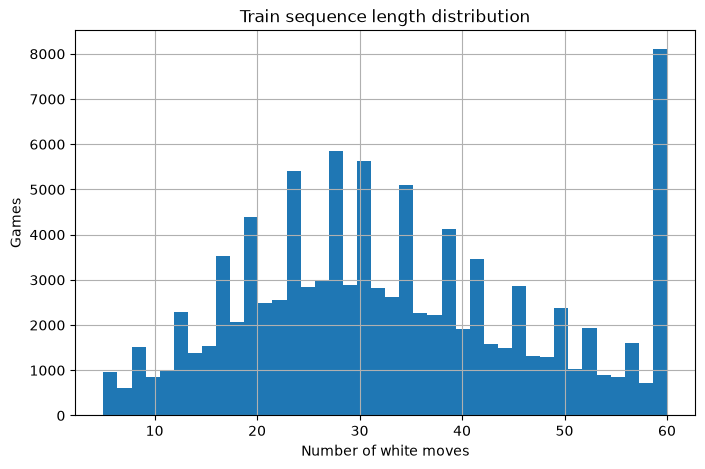

In [79]:
# LENGTH ANALYSIS

lengths = train_df["white"].str.split().str.len()

print(lengths.describe())

plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=40)
plt.xlabel("Number of white moves")
plt.ylabel("Games")
plt.title("Train sequence length distribution")
plt.grid(True)
plt.show()

In [80]:
# TRAIN / VALIDATION SPLIT

def split_train_validation(
    dataframe: pd.DataFrame,
    validation_fraction: float,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = dataframe.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_size = max(1, int(len(shuffled) * validation_fraction))

    val_df = shuffled.iloc[:val_size].reset_index(drop=True)
    fit_df = shuffled.iloc[val_size:].reset_index(drop=True)

    return fit_df, val_df


fit_df, val_df = split_train_validation(
    train_df,
    validation_fraction=CFG.VALIDATION_FRACTION,
    seed=CFG.SEED,
)

print(f"Fit rows:        {len(fit_df):,}")
print(f"Validation rows: {len(val_df):,}")

Fit rows:        91,228
Validation rows: 10,136


In [81]:
# VECTORIZERS

def create_vectorizer(
    max_tokens: int,
    max_len: int,
    name: str,
) -> keras.layers.TextVectorization:
    return keras.layers.TextVectorization(
        max_tokens=max_tokens,
        standardize=None,
        split="whitespace",
        output_mode="int",
        output_sequence_length=max_len,
        name=name,
    )


def adapt_vectorizers(
    dataframe: pd.DataFrame,
    cfg: Config,
) -> tuple[keras.layers.TextVectorization, keras.layers.TextVectorization]:
    white_vectorizer = create_vectorizer(
        max_tokens=cfg.WHITE_VOCAB_SIZE,
        max_len=cfg.MAX_LEN,
        name="white_vectorizer",
    )

    black_vectorizer = create_vectorizer(
        max_tokens=cfg.BLACK_VOCAB_SIZE,
        max_len=cfg.MAX_LEN,
        name="black_vectorizer",
    )

    white_ds = tf.data.Dataset.from_tensor_slices(
        dataframe["white"].to_numpy()
    ).batch(1024)

    black_ds = tf.data.Dataset.from_tensor_slices(
        dataframe["black"].to_numpy()
    ).batch(1024)

    white_vectorizer.adapt(white_ds)
    black_vectorizer.adapt(black_ds)

    print(f"White vocabulary size: {len(white_vectorizer.get_vocabulary()):,}")
    print(f"Black vocabulary size: {len(black_vectorizer.get_vocabulary()):,}")

    return white_vectorizer, black_vectorizer


white_vectorizer, black_vectorizer = adapt_vectorizers(train_df, CFG)

White vocabulary size: 4,363
Black vocabulary size: 5,115


In [82]:
# TENSORFLOW DATASET

def vectorize_dataframe(
    dataframe: pd.DataFrame,
    white_vectorizer: keras.layers.TextVectorization,
    black_vectorizer: keras.layers.TextVectorization,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x = white_vectorizer(
        tf.constant(dataframe["white"].to_numpy())
    ).numpy().astype("int32")

    y = black_vectorizer(
        tf.constant(dataframe["black"].to_numpy())
    ).numpy().astype("int32")

    sample_weight = (y != 0).astype("float32")

    return x, y, sample_weight


def make_dataset(
    x: np.ndarray,
    y: np.ndarray,
    sample_weight: np.ndarray,
    batch_size: int,
    shuffle: bool,
    seed: int,
) -> tf.data.Dataset:
    dataset = tf.data.Dataset.from_tensor_slices((x, y, sample_weight))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(x), 20_000),
            seed=seed,
            reshuffle_each_iteration=True,
        )

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


x_train, y_train, sw_train = vectorize_dataframe(
    fit_df,
    white_vectorizer,
    black_vectorizer,
)

x_val, y_val, sw_val = vectorize_dataframe(
    val_df,
    white_vectorizer,
    black_vectorizer,
)

train_ds = make_dataset(
    x_train,
    y_train,
    sw_train,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    seed=CFG.SEED,
)

val_ds = make_dataset(
    x_val,
    y_val,
    sw_val,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    seed=CFG.SEED,
)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

x_train: (91228, 60)
y_train: (91228, 60)


In [83]:
# MODEL

def build_model(
    white_vocab_size: int,
    black_vocab_size: int,
    cfg: Config,
) -> keras.Model:
    inputs = keras.Input(
        shape=(cfg.MAX_LEN,),
        dtype="int32",
        name="white_tokens",
    )

    x = keras.layers.Embedding(
        input_dim=white_vocab_size,
        output_dim=cfg.EMBEDDING_DIM,
        mask_zero=True,
        name="white_embedding",
    )(inputs)

    x = keras.layers.SpatialDropout1D(
        cfg.SPATIAL_DROPOUT,
        name="embedding_dropout",
    )(x)

    x = keras.layers.Bidirectional(
        keras.layers.GRU(
            cfg.RNN_UNITS,
            return_sequences=True,
            dropout=cfg.DROPOUT,
            recurrent_dropout=0.0,
        ),
        name="context_bigru",
    )(x)

    x = keras.layers.Dense(
        cfg.BOTTLENECK_DIM,
        activation="gelu",
        name="move_bottleneck",
    )(x)

    x = keras.layers.Dropout(
        cfg.DROPOUT,
        name="bottleneck_dropout",
    )(x)

    outputs = keras.layers.Dense(
        black_vocab_size,
        activation="softmax",
        dtype="float32",
        name="black_move",
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="white_to_black_bigru",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=cfg.LEARNING_RATE,
            clipnorm=1.0,
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="token_acc"),
        ],
    )

    return model


def count_trainable_parameters(model: keras.Model) -> int:
    return int(
        np.sum([
            np.prod(weight.shape)
            for weight in model.trainable_weights
        ])
    )


def assert_parameter_budget(
    model: keras.Model,
    max_trainable_params: int = 6_000_000,
) -> None:
    trainable_params = count_trainable_parameters(model)

    print(f"Trainable parameters: {trainable_params:,}")

    if trainable_params >= max_trainable_params:
        raise ValueError(
            f"Model has {trainable_params:,} trainable parameters. "
            f"It must stay below {max_trainable_params:,}."
        )


model = build_model(
    white_vocab_size=len(white_vectorizer.get_vocabulary()),
    black_vocab_size=len(black_vectorizer.get_vocabulary()),
    cfg=CFG,
)

model.summary()
assert_parameter_budget(model)

Model: "white_to_black_bigru"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ white_tokens        │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ white_embedding     │ (None, 60, 128)   │    558,464 │ white_tokens[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 60, 128)   │          0 │ white_embedding[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, 60)        │          0 │ white_tokens[0][… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_bigru       │ (None, 60, 512)   │    592,896 │ embedding_dropou… │
│ (Bidirectional)     │                   │            │ not_equal_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ move_bottleneck     │ (None, 60, 256)   │    131,328 │ context_bigru[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_dropout  │ (None, 60, 256)   │          0 │ move_bottleneck[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ black_move (Dense)  │ (None, 60, 5115)  │  1,314,555 │ bottleneck_dropo… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,597,243 (9.91 MB)

 Trainable params: 2,597,243 (9.91 MB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 2,597,243


In [84]:
#TRAINING

def train_model(
    model: keras.Model,
    train_ds: tf.data.Dataset,
    val_ds: tf.data.Dataset,
    cfg: Config,
) -> keras.callbacks.History:
    artifact_dir = Path(cfg.ARTIFACT_DIR)
    artifact_dir.mkdir(parents=True, exist_ok=True)

    best_weights_path = artifact_dir / cfg.BEST_WEIGHTS_NAME

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(best_weights_path),
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            mode="min",
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            mode="min",
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            mode="min",
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.EPOCHS,
        callbacks=callbacks,
    )

    if best_weights_path.exists():
        model.load_weights(str(best_weights_path))

    return history


history = train_model(model, train_ds, val_ds, CFG)

Epoch 1/30


/home/francesco/chess_project/Deep-Learning-Project---July-2026/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1373/1426 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - loss: 4.9653 - token_acc: 0.1026 
Epoch 1: val_loss improved from None to 4.27086, saving model to artifacts/white_to_black_bigru_best.weights.h5

Epoch 1: finished saving model to artifacts/white_to_black_bigru_best.weights.h5
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 135s 92ms/step - loss: 4.9445 - token_acc: 0.1046 - val_loss: 4.2709 - val_token_acc: 0.1691 - learning_rate: 0.0010
Epoch 2/30
1375/1426 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - loss: 4.2105 - token_acc: 0.1764 
Epoch 2: val_loss improved from 4.27086 to 3.97930, saving model to artifacts/white_to_black_bigru_best.weights.h5

Epoch 2: finished saving model to artifacts/white_to_black_bigru_best.weights.h5
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 129s 90ms/step - loss: 4.2067 - token_acc: 0.1768 - val_loss: 3.9793 - val_token_acc: 0.2045 - learning_rate: 0.0010
Epoch 3/30
1394/1426 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - loss: 4.0210 - token_acc: 0.1982
Epoch 3: val_loss improved from 3.97930 to 3.8488

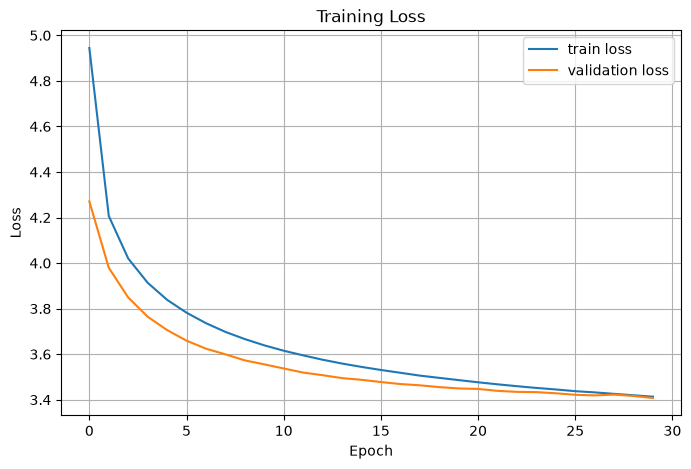

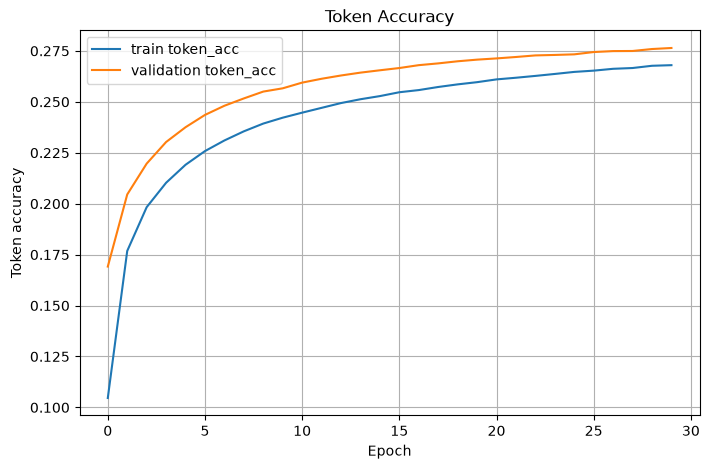

In [85]:
# TRAINING PLOTS

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["token_acc"], label="train token_acc")
plt.plot(history_df["val_token_acc"], label="validation token_acc")
plt.xlabel("Epoch")
plt.ylabel("Token accuracy")
plt.title("Token Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [86]:
# INFERENCE

def ids_to_tokens(
    ids: np.ndarray,
    vocabulary: list[str],
    limit: int,
) -> list[str]:
    decoded: list[str] = []

    for token_id in ids[:limit]:
        token_id = int(token_id)

        if token_id <= 0 or token_id >= len(vocabulary):
            break

        token = vocabulary[token_id]

        if token == "":
            break

        decoded.append(token)

    return decoded


def predict_black_moves_batch(
    model: keras.Model,
    white_texts: list[str],
    white_vectorizer: keras.layers.TextVectorization,
    black_vocabulary: list[str],
    cfg: Config,
) -> list[list[str]]:
    x = white_vectorizer(
        tf.constant(white_texts)
    ).numpy().astype("int32")

    probabilities = model.predict(
        x,
        batch_size=cfg.PREDICTION_BATCH_SIZE,
        verbose=0,
    )

    predicted_ids = np.argmax(probabilities, axis=-1)

    decoded_batch: list[list[str]] = []

    for white_text, row_ids in zip(white_texts, predicted_ids, strict=False):
        limit = min(len(white_text.split()), cfg.MAX_LEN)
        decoded = ids_to_tokens(
            ids=row_ids,
            vocabulary=black_vocabulary,
            limit=limit,
        )
        decoded_batch.append(decoded[:limit])

    return decoded_batch


def predict_black_moves(
    model: keras.Model,
    white_text: str,
    white_vectorizer: keras.layers.TextVectorization,
    black_vocabulary: list[str],
    cfg: Config,
) -> list[str]:
    return predict_black_moves_batch(
        model=model,
        white_texts=[white_text],
        white_vectorizer=white_vectorizer,
        black_vocabulary=black_vocabulary,
        cfg=cfg,
    )[0]


black_vocabulary = black_vectorizer.get_vocabulary()

In [87]:
# SURVIVAL AUC

def correct_prefix_length(
    true_tokens: list[str],
    predicted_tokens: list[str],
) -> int:
    correct = 0

    for true_token, predicted_token in zip(
        true_tokens,
        predicted_tokens,
        strict=False,
    ):
        if true_token != predicted_token:
            break

        correct += 1

    return correct


def batched_ranges(
    length: int,
    batch_size: int,
) -> list[tuple[int, int]]:
    return [
        (start, min(start + batch_size, length))
        for start in range(0, length, batch_size)
    ]


def evaluate_survival_auc(
    dataframe: pd.DataFrame,
    model: keras.Model,
    white_vectorizer: keras.layers.TextVectorization,
    black_vocabulary: list[str],
    cfg: Config,
    max_examples: int | None = None,
) -> dict[str, Any]:
    eval_df = dataframe if max_examples is None else dataframe.head(max_examples)
    eval_df = eval_df.reset_index(drop=True)

    prefix_lengths: list[int] = []

    token_correct = 0
    token_total = 0
    first_move_correct = 0
    exact_sequence_correct = 0

    for start, end in batched_ranges(
        len(eval_df),
        cfg.PREDICTION_BATCH_SIZE,
    ):
        batch = eval_df.iloc[start:end]

        predictions = predict_black_moves_batch(
            model=model,
            white_texts=batch["white"].tolist(),
            white_vectorizer=white_vectorizer,
            black_vocabulary=black_vocabulary,
            cfg=cfg,
        )

        for true_text, predicted_tokens in zip(
            batch["black"].tolist(),
            predictions,
            strict=False,
        ):
            true_tokens = true_text.split()[:cfg.MAX_LEN]
            predicted_tokens = predicted_tokens[:len(true_tokens)]

            prefix_len = correct_prefix_length(
                true_tokens=true_tokens,
                predicted_tokens=predicted_tokens,
            )

            prefix_lengths.append(prefix_len)

            first_move_correct += int(prefix_len >= 1)
            exact_sequence_correct += int(prefix_len == len(true_tokens))

            for true_token, predicted_token in zip(
                true_tokens,
                predicted_tokens,
                strict=False,
            ):
                token_correct += int(true_token == predicted_token)
                token_total += 1

    max_curve_len = min(
        cfg.MAX_LEN,
        max((len(text.split()) for text in eval_df["black"]), default=0),
    )

    survival_curve = {
        int(k): float(np.mean([
            prefix_len >= k
            for prefix_len in prefix_lengths
        ]))
        for k in range(1, max_curve_len + 1)
    }

    survival_auc = float(np.mean(prefix_lengths)) if prefix_lengths else 0.0

    return {
        "n_examples": int(len(eval_df)),
        "survival_auc": survival_auc,
        "mean_correct_prefix": survival_auc,
        "first_move_accuracy": (
            float(first_move_correct / len(eval_df))
            if len(eval_df)
            else 0.0
        ),
        "exact_sequence_accuracy": (
            float(exact_sequence_correct / len(eval_df))
            if len(eval_df)
            else 0.0
        ),
        "token_accuracy": (
            float(token_correct / token_total)
            if token_total
            else 0.0
        ),
        "survival_curve": survival_curve,
        "prefix_lengths": prefix_lengths,
    }


def print_metrics(metrics: dict[str, Any]) -> None:
    print(f"Examples:                {metrics['n_examples']:,}")
    print(f"Survival AUC:            {metrics['survival_auc']:.4f}")
    print(f"First move accuracy:     {metrics['first_move_accuracy']:.4f}")
    print(f"Token accuracy:          {metrics['token_accuracy']:.4f}")
    print(f"Exact sequence accuracy: {metrics['exact_sequence_accuracy']:.4f}")


def plot_survival_curve(metrics: dict[str, Any]) -> None:
    curve = metrics["survival_curve"]

    if not curve:
        print("No survival curve available.")
        return

    plt.figure(figsize=(8, 5))
    plt.plot(list(curve.keys()), list(curve.values()), marker="o")
    plt.xlabel("k")
    plt.ylabel("S(k)")
    plt.title("Survival Curve")
    plt.grid(True)
    plt.show()

Validation metrics without opening book
Examples:                10,136
Survival AUC:            1.6584
First move accuracy:     0.6664
Token accuracy:          0.2764
Exact sequence accuracy: 0.0010


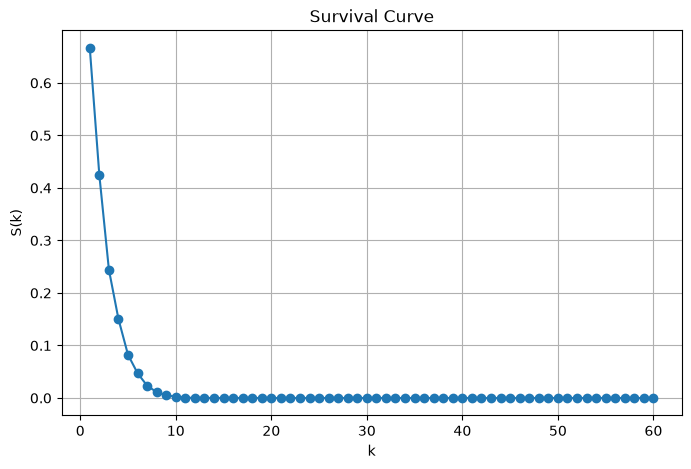

In [88]:
# BASELINE VALIDATION

print("Validation metrics without opening book")

val_metrics = evaluate_survival_auc(
    dataframe=val_df,
    model=model,
    white_vectorizer=white_vectorizer,
    black_vocabulary=black_vocabulary,
    cfg=CFG,
    max_examples=None,
)

print_metrics(val_metrics)
plot_survival_curve(val_metrics)

Validation metrics without opening book
Examples:                10,136
Survival AUC:            1.6584
First move accuracy:     0.6664
Token accuracy:          0.2764
Exact sequence accuracy: 0.0010


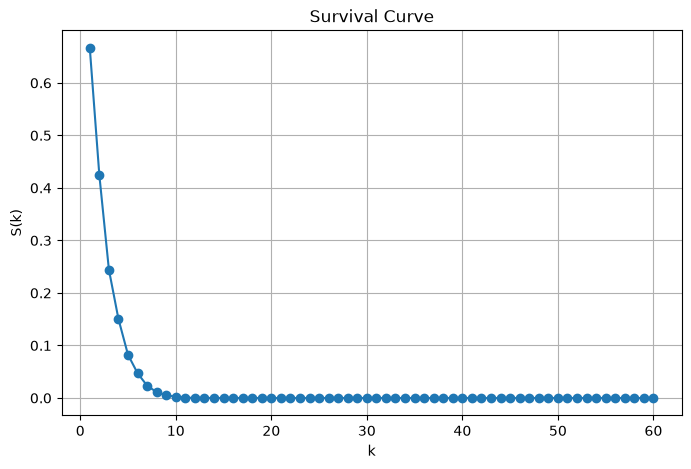


Full test metrics without opening book
Examples:                17,888
Survival AUC:            1.6862
First move accuracy:     0.6720
Token accuracy:          0.2792
Exact sequence accuracy: 0.0004


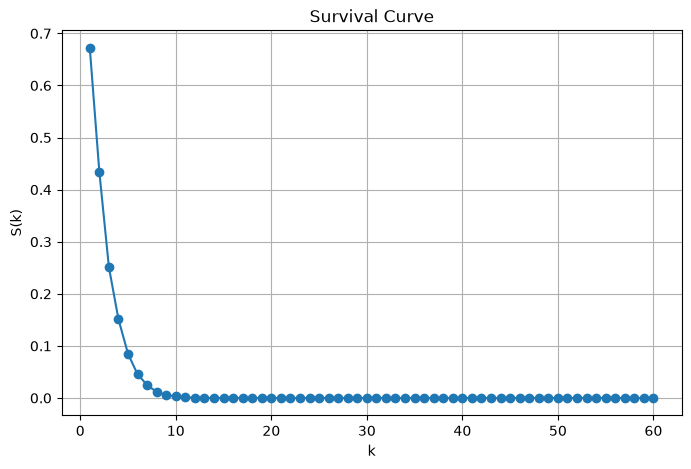

In [89]:
# FINAL VALIDATION AND TEST 

print("Validation metrics without opening book")

val_metrics = evaluate_survival_auc(
    dataframe=val_df,
    model=model,
    white_vectorizer=white_vectorizer,
    black_vocabulary=black_vocabulary,
    cfg=CFG,
    max_examples=None,
)

print_metrics(val_metrics)
plot_survival_curve(val_metrics)


print("\nFull test metrics without opening book")

test_metrics = evaluate_survival_auc(
    dataframe=test_df,
    model=model,
    white_vectorizer=white_vectorizer,
    black_vocabulary=black_vocabulary,
    cfg=CFG,
    max_examples=None,
)

print_metrics(test_metrics)
plot_survival_curve(test_metrics)

In [90]:
# QUALITY EXAMPLES

sample_df = test_df.sample(
    n=min(5, len(test_df)),
    random_state=CFG.SEED,
)

for _, row in sample_df.iterrows():
    predicted_black = predict_black_moves(
        model=model,
        white_text=row["white"],
        white_vectorizer=white_vectorizer,
        black_vocabulary=black_vocabulary,
        cfg=CFG,
    )

    print("=" * 100)
    print("White:      ", row["white"])
    print("True black: ", row["black"])
    print("Pred black: ", " ".join(predicted_black))

White:       e4 Nf3 Bb5 O-O c3 Ba4 Bb3 Bc2 Re1 h3 d4 Qxf3 d5 b4 Bg5 Nd2 cxb4 Nf1 bxc5 Ng3 Be3 Nf5 Nxe7 Qf5+ Qf3 Qg3
True black:  e5 Nc6 d6 Bd7 a6 b5 Na5 Nf6 Bg4 Bh5 Bxf3 Be7 O-O Nb7 a5 axb4 Qd7 c5 Nxc5 h6 b4 Kh7 Qxe7 g6 Kg7 Nfxe4
Pred black:  e5 Nc6 d6 d6 a6 b5 Na5 Nf6 Bg4 Ne5 Bxf3 c5 Na5 Bb6 a5 axb4 Rxa1+ c5 dxc5 h6 g5 Ne7 Qxe7 Kh8 Ng5 Qxg2#
White:       e4 Nf3 Nc3 d4 Nxd4 Nxc6 Qd4 Be3 Bxd4 e5 Nxd5 Bd3 Be3 Be4 Bc1 O-O f4 exd6 Bc6 Ba4 Rf2 b3 Rf1 Rxe1 Kf2 Kg3 Bb2 Bxa1 Bd7 Kg4 h3 Bf5 Kxh5 c3
True black:  e5 Nc6 Nf6 exd4 Qe7 bxc6 Qc5 Qxd4 Be7 Nd5 cxd5 c5 d4 Rb8 O-O Re8 d6 Bxd6 Re2 Bb7 Rbe8 Re1+ R8e2 Rxe1+ Rh1 Rg1 Rxa1 g5 Bxf4+ Bxg2 Be4 h5+ Bxf5 d3
Pred black:  c5 Nc6 Nf6 exd4 Bc5 bxc6 Qb6 Bxd4 Nf6 Nd5 cxd5 O-O O-O O-O O-O O-O d6 cxd6 Rb8 Re2 Rab8 Rfe8 Rxe1+ Rxe1+ Bd4+ Rxa2 Bxa1 Rxb2 Nf5+ h5 h5 h5+ g6 Qf1#
White:       d4 c4 e3 cxd5 Nc3 a3 b4 Bb2 Nf3 Qc2 Bd3 Ng5 h3 f4 g4 hxg4 Be2 Nd1 Nxe3 Bc1 Qxc6 Qxa8+ Rxc1 axb4 Kf1 Qb7 Ke1 Bd1 Qxd5 Be2 Qd2 Kd1 Kc2 Qd4+ Qd2+ Qc3 Bd3 Kb3 Qc1+ Qxh1+ Qc6 Qd7

In [91]:
# ARTIFACTS SAVING

def extract_metric_summary(metrics: dict[str, Any]) -> dict[str, float]:
    return {
        "survival_auc": float(metrics["survival_auc"]),
        "first_move_accuracy": float(metrics["first_move_accuracy"]),
        "token_accuracy": float(metrics["token_accuracy"]),
        "exact_sequence_accuracy": float(metrics["exact_sequence_accuracy"]),
    }


def save_artifacts(
    model: keras.Model,
    white_vectorizer: keras.layers.TextVectorization,
    black_vectorizer: keras.layers.TextVectorization,
    cfg: Config,
    val_metrics: dict[str, Any] | None = None,
    test_metrics: dict[str, Any] | None = None,
) -> tuple[Path, Path]:
    artifact_dir = Path(cfg.ARTIFACT_DIR)
    artifact_dir.mkdir(parents=True, exist_ok=True)

    final_weights_path = artifact_dir / cfg.FINAL_WEIGHTS_NAME
    metadata_path = artifact_dir / cfg.METADATA_NAME

    model.save_weights(str(final_weights_path))

    metadata = {
        "model_type": "neural_only_bigru",
        "config": asdict(cfg),
        "white_vocabulary": white_vectorizer.get_vocabulary(),
        "black_vocabulary": black_vectorizer.get_vocabulary(),
        "final_metrics": {
            "validation": (
                extract_metric_summary(val_metrics)
                if val_metrics is not None
                else None
            ),
            "test": (
                extract_metric_summary(test_metrics)
                if test_metrics is not None
                else None
            ),
        },
    }

    metadata_path.write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    print(f"Saved weights:  {final_weights_path}")
    print(f"Saved metadata: {metadata_path}")

    return final_weights_path, metadata_path


final_weights_path, metadata_path = save_artifacts(
    model=model,
    white_vectorizer=white_vectorizer,
    black_vectorizer=black_vectorizer,
    cfg=CFG,
    val_metrics=val_metrics,
    test_metrics=test_metrics,
)

Saved weights:  artifacts/white_to_black_bigru_final.weights.h5
Saved metadata: artifacts/white_to_black_metadata.json


In [92]:
# RELOAD CHECK

def load_vectorizer_from_vocabulary(
    vocabulary: list[str],
    max_tokens: int,
    max_len: int,
    name: str,
) -> keras.layers.TextVectorization:
    vectorizer = create_vectorizer(
        max_tokens=max_tokens,
        max_len=max_len,
        name=name,
    )

    vectorizer.set_vocabulary(vocabulary)

    return vectorizer


def load_config_from_metadata(metadata_config: dict[str, Any]) -> Config:
    valid_config_keys = set(Config.__dataclass_fields__.keys())

    clean_config = {
        key: value
        for key, value in metadata_config.items()
        if key in valid_config_keys
    }

    return Config(**clean_config)


def load_artifacts(
    artifact_dir: str,
    weights_name: str | None = None,
    metadata_name: str | None = None,
) -> tuple[
    keras.Model,
    keras.layers.TextVectorization,
    keras.layers.TextVectorization,
    Config,
]:
    artifact_path = Path(artifact_dir)
    metadata_path = artifact_path / (metadata_name or CFG.METADATA_NAME)

    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

    loaded_cfg = load_config_from_metadata(metadata["config"])

    if weights_name is not None:
        loaded_cfg = Config(
            **{
                **asdict(loaded_cfg),
                "FINAL_WEIGHTS_NAME": weights_name,
            }
        )

    loaded_white_vectorizer = load_vectorizer_from_vocabulary(
        vocabulary=metadata["white_vocabulary"],
        max_tokens=loaded_cfg.WHITE_VOCAB_SIZE,
        max_len=loaded_cfg.MAX_LEN,
        name="white_vectorizer",
    )

    loaded_black_vectorizer = load_vectorizer_from_vocabulary(
        vocabulary=metadata["black_vocabulary"],
        max_tokens=loaded_cfg.BLACK_VOCAB_SIZE,
        max_len=loaded_cfg.MAX_LEN,
        name="black_vectorizer",
    )

    loaded_model = build_model(
        white_vocab_size=len(metadata["white_vocabulary"]),
        black_vocab_size=len(metadata["black_vocabulary"]),
        cfg=loaded_cfg,
    )

    loaded_model.load_weights(
        str(artifact_path / loaded_cfg.FINAL_WEIGHTS_NAME)
    )

    return (
        loaded_model,
        loaded_white_vectorizer,
        loaded_black_vectorizer,
        loaded_cfg,
    )


loaded_model, loaded_white_vectorizer, loaded_black_vectorizer, loaded_cfg = load_artifacts(
    CFG.ARTIFACT_DIR
)

assert_parameter_budget(loaded_model)

print("Reload OK.")
print("Loaded artifact dir:", loaded_cfg.ARTIFACT_DIR)
print("Loaded final weights:", loaded_cfg.FINAL_WEIGHTS_NAME)
print("Loaded model type: neural-only BiGRU")

Trainable parameters: 2,597,243
Reload OK.
Loaded artifact dir: artifacts
Loaded final weights: white_to_black_bigru_final.weights.h5
Loaded model type: neural-only BiGRU


/home/francesco/chess_project/Deep-Learning-Project---July-2026/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/francesco/chess_project/Deep-Learning-Project---July-2026/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam_6', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [93]:
# COPY ARTIFACTS TO GOOGLE DRIVE
# Run this cell only in Colab.

# def copy_artifacts_to_drive(
#     source_dir: str,
#     drive_target_dir: str = "/content/drive/MyDrive/chess_white_to_black_artifacts",
# ) -> None:
#     from google.colab import drive
#
#     drive.mount("/content/drive")
#
#     src = Path(source_dir)
#     dst = Path(drive_target_dir)
#
#     shutil.copytree(src, dst, dirs_exist_ok=True)
#
#     print(f"Copied artifacts to: {dst}")
#
#     for path in dst.glob("*"):
#         size_mb = round(path.stat().st_size / 1024 / 1024, 2)
#         print(path.name, size_mb, "MB")
#
#
# copy_artifacts_to_drive(CFG.ARTIFACT_DIR)